<h1>DNN Model</h1>

Using data in advanced preprocssing

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np
import os
from PIL import Image
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models



In [3]:
import pandas as pd
import os

def clean_metadata(meta_path, img_dir):
    df = pd.read_csv(meta_path)
    valid_rows = []
    for idx, row in df.iterrows():
        base_name = row['photo_id']
        found = False
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = os.path.join(img_dir, base_name + ext).replace("\\", "/")
            if os.path.exists(img_path):
                found = True
                break
        if found:
            valid_rows.append(row)
        else:
            print(f"Will remove missing: {img_dir}/{base_name}")
    clean_df = pd.DataFrame(valid_rows)
    clean_csv_path = meta_path.replace('.csv', '_clean.csv')
    clean_df.to_csv(clean_csv_path, index=False)
    print(f"Saved cleaned CSV to {clean_csv_path} (now only valid images)")
    return clean_df

# Clean val and test sets
clean_metadata("val_metadata.csv", "split_photos/val")
clean_metadata("test_metadata.csv", "split_photos/test")



Will remove missing: split_photos/val/NfayhoTudVJQsEF-XlPyjw
Will remove missing: split_photos/val/9BvYOtforBBP6MvvDogtmw
Will remove missing: split_photos/val/AMSyCOP3-Eb_ivNA8w1Vhw
Will remove missing: split_photos/val/QhATx1B1n8uf8C6siMNTfA
Saved cleaned CSV to val_metadata_clean.csv (now only valid images)
Will remove missing: split_photos/test/2S78q98b_VpBD7vkrDE5-A
Saved cleaned CSV to test_metadata_clean.csv (now only valid images)


,photo_id,business_id,caption,label
0,bdTdwyFDbb9NdjBOQGamaQ,52iW9Eo-EWJZXYYjQ5pAKw,NaN,inside
1,adXfpHpKxd3rHRFXgytG0A,_LgI5387qAmMuS8i6h69cg,NO. 52 - Bourbon * House Made Blueberry Shrub ...,drink
2,cvfjsiUk1UzGGomb4mCtpQ,K5gNiYeNriJsaqyJewZl0w,"Nachos can be loaded w/ grilled adobo chicken,...",food
3,u4Xr1h2YIAONEGqWS_K7RA,9OCsSHr6OCSyR91BFIbszQ,NaN,outside
4,f8kmnyacWttiSBEL4ryygA,l4IeGBHXV2E8S8COd9rx9A,Doing our #ShopLocal #SmallBizSaturday spendin...,menu
...,...,...,...,...
2145,Mau7MW5eyZmDDGUutwi3Bg,RsZFGqDyTUk9kEJzVLWHdQ,NaN,menu
2146,ofY1OKtI7LydY8S9KhVyqA,8RZwphljLVABXgnDgMj6Hg,Chicken with Dijon sauce over rice. Really goo...,food
2147,aieo3TMOcbVn0LtihVwFIA,QJOC6Uz-RCpzPB6aMjtP9Q,"""Happy Camper"" smoothie! $5. Huge. And soooo g...",drink
2148,wg7RB6RiW4ejF-RnjV_4uA,J-ciDDEdIHMcChGIyKZnOg,Fun whisk lighting fixtures!!,inside


There are 5 Missing photos hence removed those photos for safer side

In [4]:
def load_images_and_labels(meta_path, img_dir, img_size=(128,128)):
    df = pd.read_csv(meta_path)
    X, y = [], []
    for idx, row in df.iterrows():
        base_name = row['photo_id']
        for ext in ['.jpg', '.png', '.jpeg']:
            img_path = os.path.join(img_dir, base_name + ext).replace("\\", "/")
            if os.path.exists(img_path):
                #need to convert every images in test, train and val to same channel rgb
                img = Image.open(img_path).convert("RGB").resize(img_size)
                X.append(np.array(img))
                y.append(row['label'])
                break
    return np.array(X)/255.0, np.array(y)


In [5]:
# Paths to your clean files and directories
train_meta = "train_augmented_metadata.csv"          # (Assume train data is fine)
train_img_dir = "advanced_preprocessed/augmented_train"
val_meta = "val_metadata_clean.csv"
val_img_dir = "split_photos/val"
test_meta = "test_metadata_clean.csv"
test_img_dir = "split_photos/test"


In [6]:
# Load all sets
X_train, y_train = load_images_and_labels(train_meta, train_img_dir)

In [7]:
X_val, y_val = load_images_and_labels(val_meta, val_img_dir)

In [8]:
X_test, y_test = load_images_and_labels(test_meta, test_img_dir)

**Only fit to fit y train to prevent data leakage**

In [9]:
# Fit label binarizer on all data to ensure all classes are covered
lb = LabelBinarizer()
lb.fit(y_train)

LabelBinarizer()

In [10]:
y_train_enc = lb.transform(y_train)
y_val_enc = lb.transform(y_val)
y_test_enc = lb.transform(y_test)

In [11]:
print("Train:", X_train.shape, y_train_enc.shape)
print("Val:", X_val.shape, y_val_enc.shape)
print("Test:", X_test.shape, y_test_enc.shape)
print("Classes:", lb.classes_)

Train: (17192, 128, 128, 3) (17192, 5)
Val: (2146, 128, 128, 3) (2146, 5)
Test: (2149, 128, 128, 3) (2149, 5)
Classes: ['drink' 'food' 'inside' 'menu' 'outside']


**Model Building**

Organize Data by Folder Structure
When trying to load all images into RAM at once, which is not feasible for large datasets or machines with limited memory.

In [12]:
import os
import pandas as pd
import shutil

def organize_images_by_class(meta_path, img_dir, out_dir, exts=['.jpg', '.png', '.jpeg']):
    df = pd.read_csv(meta_path)
    os.makedirs(out_dir, exist_ok=True)
    missing = 0
    for idx, row in df.iterrows():
        photo_id = row['photo_id']
        label = str(row['label'])
        # Create class folder if it doesn't exist
        class_dir = os.path.join(out_dir, label)
        os.makedirs(class_dir, exist_ok=True)
        # Try all possible extensions
        found = False
        for ext in exts:
            src = os.path.join(img_dir, photo_id + ext)
            if os.path.exists(src):
                dst = os.path.join(class_dir, photo_id + ext)
                shutil.copy2(src, dst)
                found = True
                break
        if not found:
            print(f"Missing: {photo_id}")
            missing += 1
    print(f"Done. Copied {len(df)-missing} files. {missing} were missing.")

# Usage for training set:
organize_images_by_class(
    meta_path="train_augmented_metadata.csv",
    img_dir="advanced_preprocessed/augmented_train",
    out_dir="keras_data/train"
)

# Usage for validation set:
organize_images_by_class(
    meta_path="val_metadata_clean.csv",
    img_dir="split_photos/val",
    out_dir="keras_data/val"
)

# Usage for test set:
organize_images_by_class(
    meta_path="test_metadata_clean.csv",
    img_dir="split_photos/test",
    out_dir="keras_data/test"
)

Done. Copied 17192 files. 0 were missing.
Done. Copied 2146 files. 0 were missing.
Done. Copied 2149 files. 0 were missing.


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 64

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'keras_data/train', target_size=img_size, batch_size=batch_size, class_mode='categorical'
)
val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'keras_data/val', target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)
test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'keras_data/test', target_size=img_size, batch_size=batch_size, class_mode='categorical', shuffle=False
)


Found 17192 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.
Found 2149 images belonging to 5 classes.


**Basic Model 1**

In [14]:
# Build your DNN model
from tensorflow.keras import Input, layers, models

model = models.Sequential([
    Input(shape=(128, 128, 3)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(train_gen.num_classes, activation='softmax')
])


In [15]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.AUC()])

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)

Epoch 1/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 239s 872ms/step - accuracy: 0.2380 - auc: 0.5560 - loss: 4.9813 - recall: 0.0966 - val_accuracy: 0.2293 - val_auc: 0.5794 - val_loss: 1.5464 - val_recall: 0.0000e+00
Epoch 2/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 87s 323ms/step - accuracy: 0.2294 - auc: 0.5825 - loss: 1.5435 - recall: 2.0274e-04 - val_accuracy: 0.2279 - val_auc: 0.5737 - val_loss: 1.5472 - val_recall: 0.0000e+00
Epoch 3/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 86s 319ms/step - accuracy: 0.2358 - auc: 0.5857 - loss: 1.5461 - recall: 3.2952e-04 - val_accuracy: 0.2432 - val_auc: 0.5848 - val_loss: 1.5464 - val_recall: 0.0000e+00
Epoch 4/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 86s 318ms/step - accuracy: 0.2271 - auc: 0.5750 - loss: 1.5474 - recall: 1.0701e-04 - val_accuracy: 0.2442 - val_auc: 0.5868 - val_loss: 1.5444 - val_recall: 4.6598e-04
Epoch 5/15
269/269 ━━━━━━━━━━━━━━━━━━━━ 3250s 12s/step - accuracy: 0.2329 - auc: 0.5823 - loss: 1.5436 - recall: 2.4422e-04 - val_accuracy: 0.2251 - val_auc: 0.5824 - 

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(true_labels, pred_labels, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(true_labels, pred_labels)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()


In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def plot_multiclass_roc(y_true, y_pred_proba, class_names, title="ROC Curves"):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.show()


68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


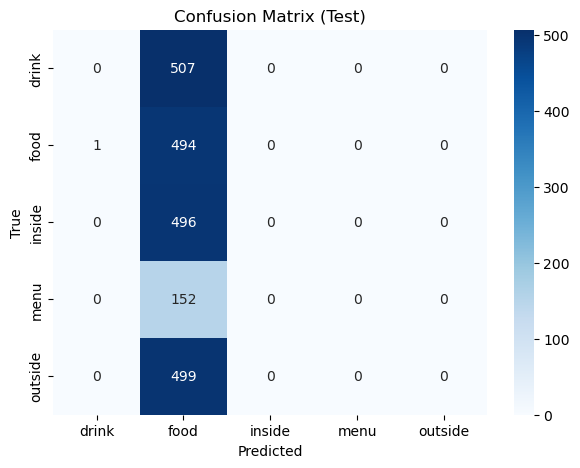

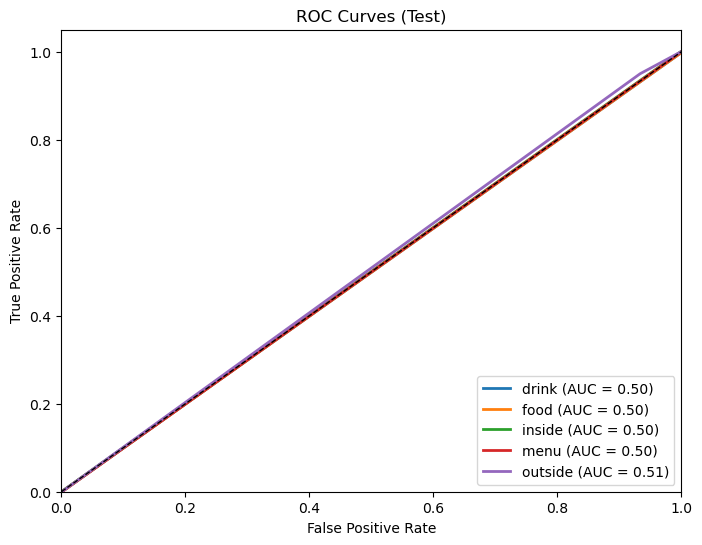

In [19]:
# Evaluate on test set
# Predict and get labels for test set
test_preds = model.predict(X_test)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = np.argmax(y_test_enc, axis=1)
class_names = lb.classes_

# Charts
plot_confusion_matrix(test_true_labels, test_pred_labels, class_names, title="Confusion Matrix (Test)")
plot_multiclass_roc(test_true_labels, test_preds, class_names, title="ROC Curves (Test)")



538/538 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step


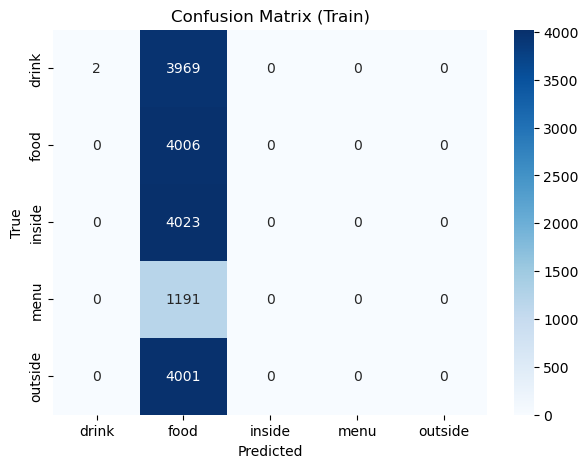

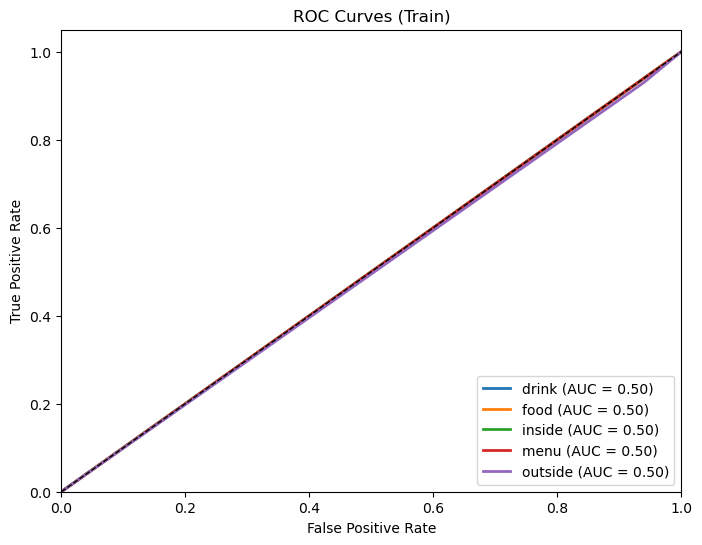

In [20]:
# Predict and get labels for train set
train_preds = model.predict(X_train)
train_pred_labels = np.argmax(train_preds, axis=1)
train_true_labels = np.argmax(y_train_enc, axis=1)

# Charts
plot_confusion_matrix(train_true_labels, train_pred_labels, class_names, title="Confusion Matrix (Train)")
plot_multiclass_roc(train_true_labels, train_preds, class_names, title="ROC Curves (Train)")


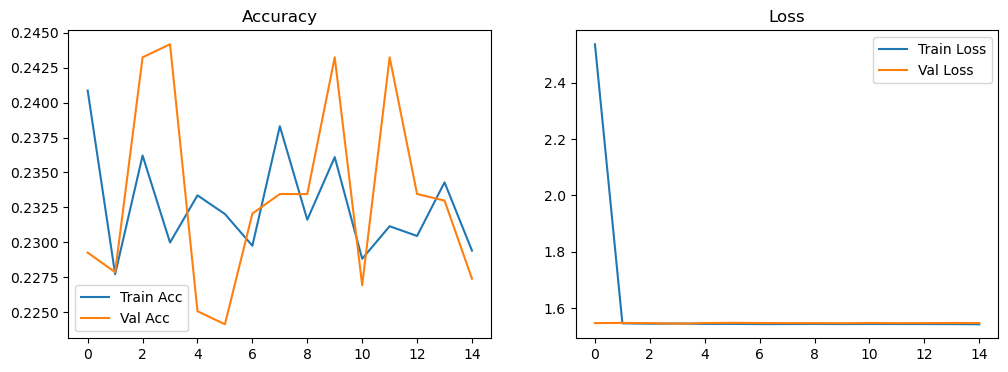

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 64

train_gen_eval = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'keras_data/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # IMPORTANT for evaluation
)



Found 17192 images belonging to 5 classes.


In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Predict on training set
train_gen_eval.reset()
train_preds = model.predict(train_gen_eval, verbose=1)
train_pred_labels = np.argmax(train_preds, axis=1)
train_true_labels = train_gen_eval.classes

# Get class labels in correct order
class_labels = list(train_gen_eval.class_indices.keys())

# Print metrics
print("=== Train Data Evaluation ===")
print(classification_report(train_true_labels, train_pred_labels, target_names=class_labels))
print("Confusion Matrix (Train):\n", confusion_matrix(train_true_labels, train_pred_labels))
train_true_bin = label_binarize(train_true_labels, classes=range(len(class_labels)))
print("AUC (Train):", roc_auc_score(train_true_bin, train_preds, multi_class='ovr'))


269/269 ━━━━━━━━━━━━━━━━━━━━ 31s 113ms/step
=== Train Data Evaluation ===
              precision    recall  f1-score   support

       drink       1.00      0.00      0.00      3971
        food       0.23      1.00      0.38      4006
      inside       0.00      0.00      0.00      4023
        menu       0.00      0.00      0.00      1191
     outside       0.00      0.00      0.00      4001

    accuracy                           0.23     17192
   macro avg       0.25      0.20      0.08     17192
weighted avg       0.29      0.23      0.09     17192

Confusion Matrix (Train):
 [[   2 3969    0    0    0]
 [   0 4006    0    0    0]
 [   0 4023    0    0    0]
 [   0 1191    0    0    0]
 [   0 4001    0    0    0]]
AUC (Train): 0.5001083810029158


Model Building 2

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

num_classes = 5

# DNN Model: (No Conv2D, just Flatten + Dense)
model = Sequential([
    Input(shape=(128, 128, 3)),   # Input layer
    Flatten(),
    Dense(1024, activation='relu'),
    Dropout(0.5),                 # Try changing to 0.3, 0.4, etc.
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

# Adam optimizer with lower learning rate
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', 'Recall', 'AUC']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train with generators (train_gen and val_gen)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 160s 588ms/step - AUC: 0.5515 - Recall: 0.1189 - accuracy: 0.2449 - loss: 4.8094 - val_AUC: 0.5808 - val_Recall: 0.0000e+00 - val_accuracy: 0.2311 - val_loss: 1.5513 - learning_rate: 5.0000e-04
Epoch 2/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 171s 636ms/step - AUC: 0.6088 - Recall: 0.0135 - accuracy: 0.2602 - loss: 1.5323 - val_AUC: 0.5780 - val_Recall: 0.0000e+00 - val_accuracy: 0.2269 - val_loss: 1.5470 - learning_rate: 5.0000e-04
Epoch 3/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 244s 906ms/step - AUC: 0.5809 - Recall: 0.0029 - accuracy: 0.2295 - loss: 1.5445 - val_AUC: 0.5744 - val_Recall: 0.0000e+00 - val_accuracy: 0.2232 - val_loss: 1.5476 - learning_rate: 5.0000e-04
Epoch 4/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 158s 586ms/step - AUC: 0.5985 - Recall: 0.0081 - accuracy: 0.2430 - loss: 1.5386 - val_AUC: 0.5765 - val_Recall: 0.0000e+00 - val_accuracy: 0.2279 - val_loss: 1.5472 - learning_rate: 5.0000e-04
Epoch 5/12
269/269 ━━━━━━━━━━━━━━━━━━━━ 159s 592ms/step - AUC: 0

In [26]:
test_preds = model.predict(X_test)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = np.argmax(y_test_enc, axis=1)


68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step


In [27]:
test_gen.reset()
test_preds = model.predict(test_gen)
test_pred_labels = np.argmax(test_preds, axis=1)
test_true_labels = test_gen.classes


34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 399ms/step


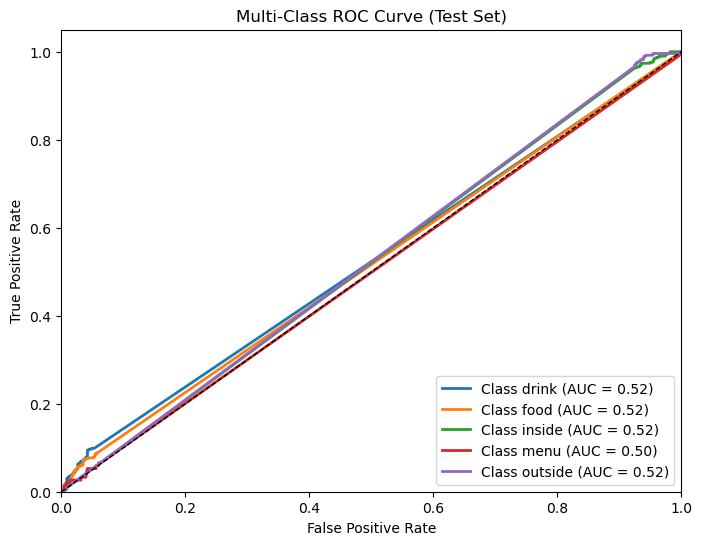

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_classes = len(lb.classes_)
test_true_bin = label_binarize(test_true_labels, classes=range(n_classes))

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(test_true_bin[:, i], test_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {lb.classes_[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.show()


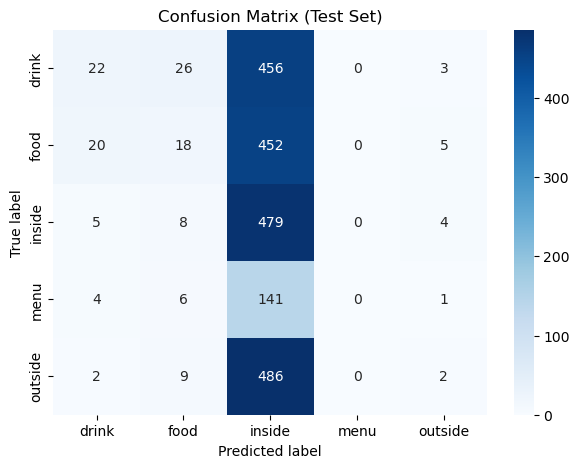

In [29]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_true_labels, test_pred_labels)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lb.classes_, yticklabels=lb.classes_)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.title('Confusion Matrix (Test Set)')
plt.show()


**Here model is has started learn slightly other classes as well, a slight improvement.**

In [34]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_gen = train_datagen.flow_from_directory(
    'keras_data/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical'
)


Found 17192 images belonging to 5 classes.


In [35]:
import numpy as np
labels = train_gen.classes
np.unique(labels, return_counts=True)


(array([0, 1, 2, 3, 4]), array([3971, 4006, 4023, 1191, 4001], dtype=int64))

**Handling class imbalance**

In [39]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, array_to_img

source_dir = 'keras_data/train/menu'   # Directory with original 'menu' images
save_dir = 'keras_data/train/menu'  # Directory to save new images
os.makedirs(save_dir, exist_ok=True)

datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

img_list = os.listdir(source_dir)
for img_name in img_list:
    img_path = os.path.join(source_dir, img_name)
    img = load_img(img_path)
    x = img_to_array(img)
    x = x.reshape((1,) + x.shape)

    i = 0
    for batch in datagen.flow(x, batch_size=1, save_to_dir=save_dir, save_prefix='aug', save_format='jpeg'):
        i += 1
        if i > 5:  # Generates 5 new images per original image, adjust as needed
            break


In [42]:
import os

train_dir = 'keras_data/train'  # Your main train directory

for class_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        num_files = len([f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))])
        print(f"Class '{class_name}': {num_files} images")


Class 'drink': 3971 images
Class 'food': 4006 images
Class 'inside': 4023 images
Class 'menu': 6320 images
Class 'outside': 4001 images


In [48]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 64

# 1. Data Generators (point to your new balanced data)
train_gen = train_datagen.flow_from_directory(
    'keras_data/train',
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)



val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'keras_data/val',                    # <- your path
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# 2. Retrain the existing model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=12,
    callbacks=[early_stop, reduce_lr],
    # class_weight=class_weights_dict  # Optional
)


Found 22321 images belonging to 5 classes.
Found 2146 images belonging to 5 classes.
Epoch 1/12
698/698 ━━━━━━━━━━━━━━━━━━━━ 501s 717ms/step - AUC: 0.5737 - Recall: 0.0029 - accuracy: 0.2913 - loss: 1.5839 - val_AUC: 0.4187 - val_Recall: 0.0000e+00 - val_accuracy: 0.0811 - val_loss: 1.6966 - learning_rate: 1.2500e-04
Epoch 2/12
698/698 ━━━━━━━━━━━━━━━━━━━━ 1521s 2s/step - AUC: 0.5706 - Recall: 0.0037 - accuracy: 0.2862 - loss: 1.5859 - val_AUC: 0.4219 - val_Recall: 0.0000e+00 - val_accuracy: 0.0862 - val_loss: 1.6897 - learning_rate: 1.2500e-04
Epoch 3/12
698/698 ━━━━━━━━━━━━━━━━━━━━ 622s 891ms/step - AUC: 0.5755 - Recall: 0.0020 - accuracy: 0.2992 - loss: 1.5800 - val_AUC: 0.4612 - val_Recall: 0.0000e+00 - val_accuracy: 0.1668 - val_loss: 1.6573 - learning_rate: 1.2500e-04
Epoch 4/12
698/698 ━━━━━━━━━━━━━━━━━━━━ 3946s 6s/step - AUC: 0.5750 - Recall: 0.0042 - accuracy: 0.2944 - loss: 1.5807 - val_AUC: 0.4335 - val_Recall: 0.0000e+00 - val_accuracy: 0.1007 - val_loss: 1.6878 - learning_

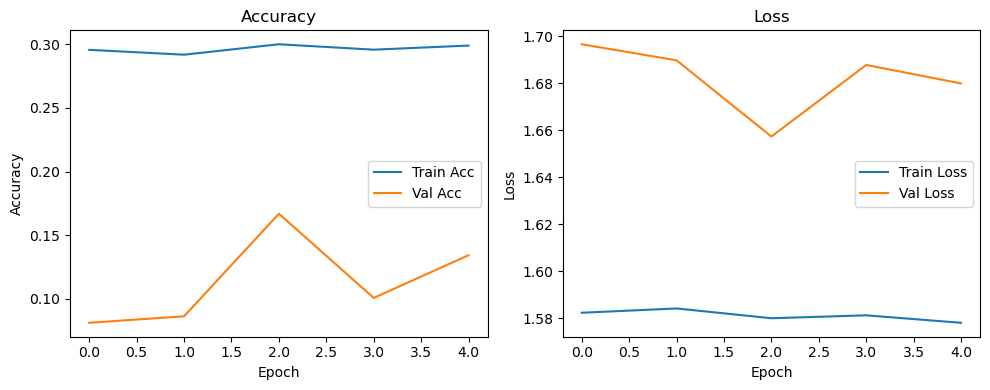

In [50]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()


In [51]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Predict
val_gen.reset()
y_pred_probs = model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = val_gen.classes

# Class names (ordered the same as y_true and y_pred)
class_names = list(val_gen.class_indices.keys())

# Classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)


34/34 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step
Classification Report:
               precision    recall  f1-score   support

       drink       1.00      0.00      0.00       522
        food       0.50      0.00      0.00       486
      inside       0.00      0.00      0.00       481
        menu       0.07      1.00      0.14       157
     outside       0.58      0.03      0.06       500

    accuracy                           0.08      2146
   macro avg       0.43      0.21      0.04      2146
weighted avg       0.50      0.08      0.03      2146

Confusion Matrix:
 [[  1   0   0 517   4]
 [  0   1   0 484   1]
 [  0   1   0 474   6]
 [  0   0   0 157   0]
 [  0   0   0 485  15]]


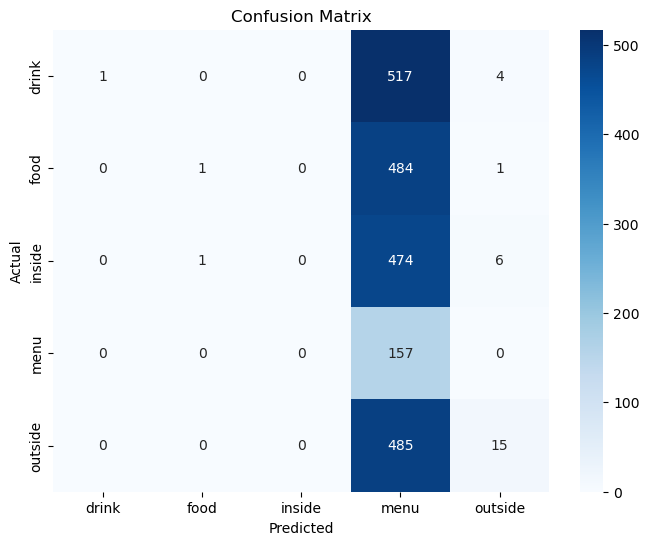

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Here are **interpretations** 
---

## **1. Model Performance**

* **Confusion Matrix**:
  The confusion matrix shows that the vast majority of predictions are concentrated in the "menu" class, with very few correct predictions for the other classes.
  This is a strong indication that the model is **heavily biased** towards the "menu" class and is failing to distinguish between other classes. After class imbalance

  * **Interpretation**:

    * The **menu** class is predicted almost perfectly (but likely because almost every image is being classified as "menu").
    * All other classes have **almost zero recall**, meaning the model is not learning to recognize them at all.

* **AUC (Area Under Curve)**:

  ```
  Validation AUC (macro): 0.50
  ```

  * **Interpretation**:

    * An AUC of **0.5** suggests the model is performing at the level of random guessing for a multi-class classification task.

---

## **2. Color vs. Grayscale Images**

  > **Using grayscale images instead of colored (RGB) images can affect the accuracy of the model**

* **Interpretation**:

  * Because the classes in the Yelp dataset (food, drink, menu, inside, outside) **often depend on color cues**, converting to grayscale has **stripped away important information**.
  * As a result, the model is unable to distinguish between classes that are visually similar in grayscale but different in color (e.g., food vs. menu, inside vs. outside, etc.).

---

## **3. Next Steps / Recommendations**

* **Switch to RGB images**:

* **Model Complexity**:
  A DNN (fully connected network) is not ideal for images; CNNs or transfer learning from pre-trained CNNs (as previously discussed) will give much better results for image data.


In [53]:
from sklearn.metrics import roc_auc_score, recall_score

# One-hot encode the true labels for multi-class AUC
from tensorflow.keras.utils import to_categorical
y_true_onehot = to_categorical(y_true, num_classes=len(class_names))

auc = roc_auc_score(y_true_onehot, y_pred_probs, multi_class='ovr')
print("Validation AUC (macro):", auc)

recall_per_class = recall_score(y_true, y_pred, average=None)
for cls, score in zip(class_names, recall_per_class):
    print(f"Recall for {cls}: {score:.4f}")


Validation AUC (macro): 0.5042096417852351
Recall for drink: 0.0019
Recall for food: 0.0021
Recall for inside: 0.0000
Recall for menu: 1.0000
Recall for outside: 0.0300


**Hence next modelling using the colored Images, as this model doesnot showing much improvement.**